In [191]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [192]:
data_path = '/content/drive/MyDrive/dane/titanic.csv'

In [193]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic_df = pd.read_csv(data_path, index_col='PassengerId')

In [194]:
titanic_df.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,98
Cabin,687


In [195]:
titanic_df = titanic_df.drop(columns=['Cabin'])
titanic_df = titanic_df.drop(columns=['Name'])
titanic_df = titanic_df.drop(columns=['Ticket'])

Ponieważ wiekszość komórek w kolumnie Cabin jest nieznana usuwam ją, kolumnę Name i Ticket również usuwam nie wprowadzają one żadnych istotnych informacji

In [196]:
def get_column_distribution(df, column):
  return df[column].value_counts(normalize=True)

In [197]:
age_prob = get_column_distribution(titanic_df, 'Age')
age_values = age_prob.index
age_probs = age_prob.values
missing_age_vals = titanic_df.Age.isna()
titanic_df.loc[missing_age_vals, 'Age'] = np.random.choice(age_values, size=missing_age_vals.sum(), p=age_probs)


Uzupełniam puste komórki w kolumnie Age według prawdopodobieństwa występowań

In [198]:
titanic_df.Embarked.isna()
most_common=titanic_df['Embarked'].mode()
titanic_df['Embarked'].fillna(most_common[0], inplace=True)


/tmp/ipykernel_2525/2757902702.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Embarked'].fillna(most_common[0], inplace=True)


W Embarked mamy tylko 2 nieznane wartości więc zastępuje je najczęściej występującą

In [199]:
mapping = {
    'C': 0,
    'Q': 1,
    'S': 2,
}

titanic_df['Embarked'] = titanic_df['Embarked'].map(mapping)
titanic_df.Embarked.value_counts()

,count
Embarked,
2,646
0,168
1,77


Koduje kolumnę Embarked używając ordinal encoding

In [200]:
class_fare=np.round(titanic_df.groupby('Pclass')['Fare'].mean(),decimals=4)
titanic_df['Fare']=titanic_df['Fare'].fillna(titanic_df['Pclass'].map(class_fare))

Uzupełniam brakujące ceny biletów średnią ceną dla danej klasy

In [201]:
titanic_df['Sex'] = titanic_df.Sex.map({
    'female': 1, 'male': 0
})
titanic_df['Sex'].value_counts()

,count
Sex,
0,577
1,314


Koduję płeć 1=kobieta 0=mężczyzna

In [202]:
new_column = pd.Series(titanic_df['SibSp']+titanic_df['Parch']+1,
                       index=titanic_df.index,
                       name='Fam_memb')
titanic_df=pd.concat([titanic_df, new_column], axis=1)

dodaję kolumnę która zawiera liczbe członków rodziny

In [203]:
is_adult = titanic_df.Age >17
titanic_df['Adult'] = 0
titanic_df.loc[is_adult, 'Adult'] = 1

dodaję kolumnę która mówi czy osoba jest dorosła czy nie

In [204]:

def boxplot(df, column_name):
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column_name].dropna(), color='lightgreen')
    plt.title(f'Distribution of {column_name} (boxplot)')
    plt.xlabel(column_name)

    plt.show()

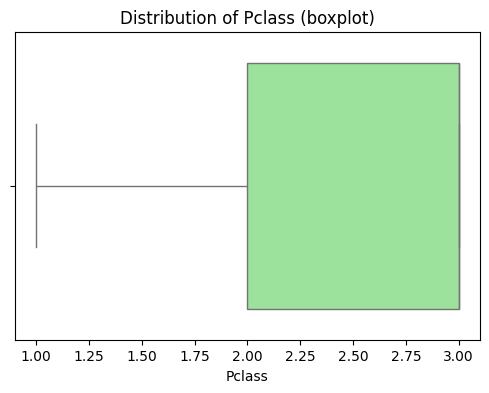

In [205]:
boxplot(titanic_df,'Pclass')

Najwięcej pasażerów wybierało 2 i 3  klase, brak outlierów

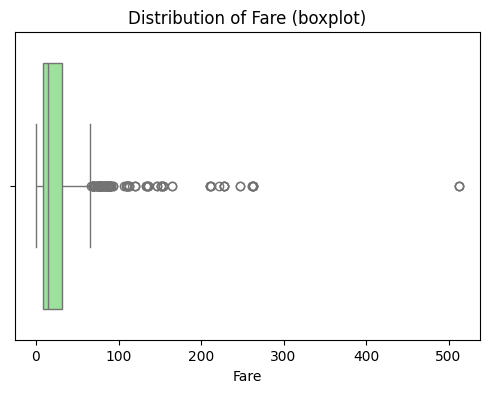

In [206]:
 boxplot(titanic_df, 'Fare')

widać na wykresie że jest dużo wartości odstających

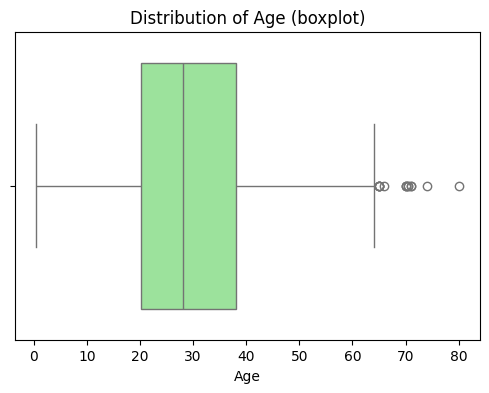

In [207]:
boxplot(titanic_df, 'Age')

Widzimy ze wiekszosc osob na statku byla mloda natomiast wystepuje troche outlierow ale nie maja one negatywnego wplywu sa to prawdziwe dane

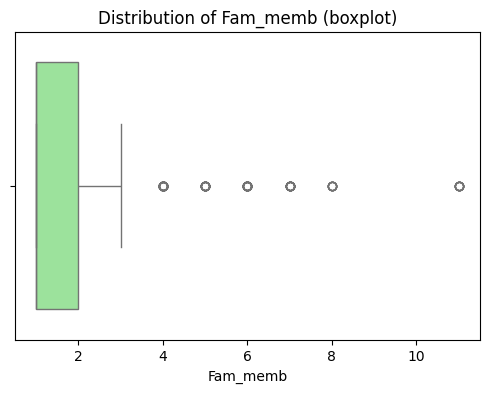

In [208]:
boxplot(titanic_df, 'Fam_memb')

widzimy ze wiekszosc osob na statku nie mialo badz nie bralo ze soba duzej rodziny lecz zdarzaja si przypadki gdzie rodzina byla wieksza (ponad 10osob) outliery w tym przypadku rowniez nie mialy by negatywego wplywu

In [209]:
def plot_correlation_matrix(df):
    corr = df.corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

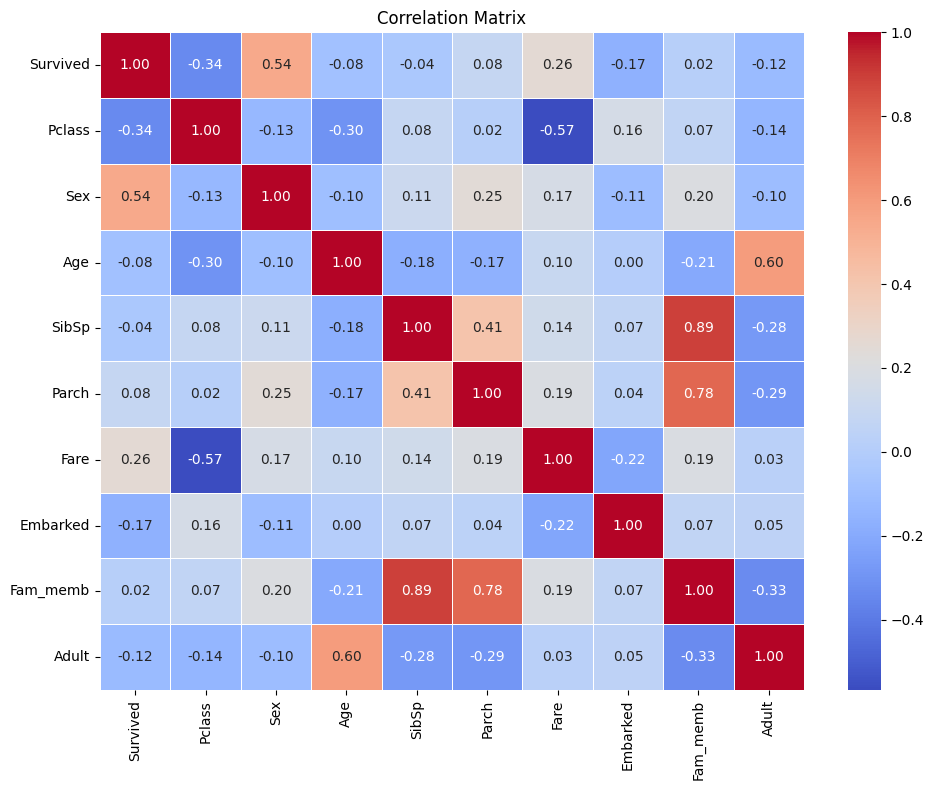

In [210]:
plot_correlation_matrix(titanic_df)

Widzimy że kobiety i ludzie którzy więcej zapłacili częściej przezywali, osoby wypływajace z Cherbourg rownież

In [211]:

def scatterplot(df, column_name, y):
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=column_name, y=y, color='darkorange', alpha=0.6)
    plt.title(f'{column_name} vs {y}')
    plt.xlabel(column_name)
    plt.ylabel('Fare')
    plt.tight_layout()
    plt.show()

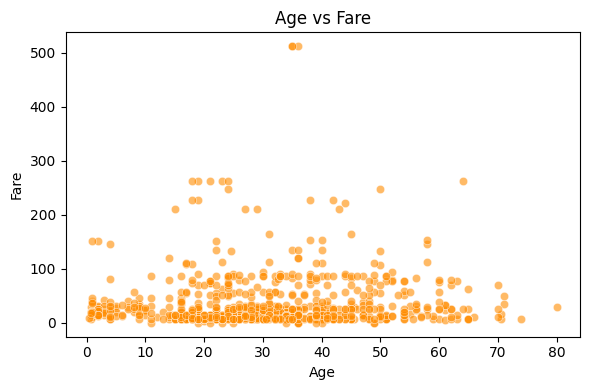

In [212]:
scatterplot(titanic_df, 'Age','Fare')

Mozna zauwazyc ze bilety dla dzieci byly tansze niz dla doroslych, starsi ludzie wybierali tansze bilety